# Validation: Data Completeness & Coverage

Check that the pipeline outputs are complete and well-formed:

1. **LSOA coverage:** expected ~32,844 LSOA 2021 per year (all English LSOAs)
2. **NaN and zero rates:** flag domains/years with excessive missing or zero values
3. **Population coverage:** LSOA populations should sum to known England totals
4. **Year coverage:** all expected years present for each domain
5. **Column consistency:** same columns across years within each domain

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

repo_root = Path.cwd()
if repo_root.name in ("validation", "nbs", "pts"):
    repo_root = repo_root.parent
while not (repo_root / "config").exists() and repo_root != repo_root.parent:
    repo_root = repo_root.parent

out_dir = repo_root / "store" / "outputs" / "default" / "lsoa"
plt.rcParams.update({"figure.dpi": 120, "figure.figsize": (12, 4)})

## 1. LSOA row counts per year

In [2]:
domains = {
    "claimant_counts": sorted((out_dir / "claimant_counts").glob("*.csv")),
    "crime": sorted((out_dir / "crime").glob("*.csv")),
    "health": sorted((out_dir / "health").glob("*.csv")),
}

coverage = []
for domain, files in domains.items():
    for f in files:
        df = pd.read_csv(f)
        geo_col = [c for c in df.columns if c.endswith("CD")][0]
        coverage.append({
            "domain": domain,
            "file": f.name,
            "n_rows": len(df),
            "n_unique_lsoa": df[geo_col].nunique(),
            "n_duplicates": len(df) - df[geo_col].nunique(),
        })

coverage_df = pd.DataFrame(coverage)
print("LSOA row counts per domain/year:")
print(coverage_df.to_string(index=False))

# Check consistency
for domain in domains:
    subset = coverage_df[coverage_df["domain"] == domain]
    row_counts = subset["n_rows"].unique()
    if len(row_counts) == 1:
        print(f"\n{domain}: consistent at {row_counts[0]} rows across {len(subset)} files")
    else:
        print(f"\n{domain}: INCONSISTENT row counts: {sorted(row_counts)}")
    if subset["n_duplicates"].sum() > 0:
        print(f"  WARNING: duplicate LSOA codes detected!")

LSOA row counts per domain/year:
         domain                     file  n_rows  n_unique_lsoa  n_duplicates
claimant_counts claimant_counts_2014.csv   33749          33749             0
claimant_counts claimant_counts_2015.csv   33749          33749             0
claimant_counts claimant_counts_2016.csv   33749          33749             0
claimant_counts claimant_counts_2017.csv   33749          33749             0
claimant_counts claimant_counts_2018.csv   33749          33749             0
claimant_counts claimant_counts_2019.csv   33749          33749             0
claimant_counts claimant_counts_2020.csv   33749          33749             0
claimant_counts claimant_counts_2021.csv   33749          33749             0
claimant_counts claimant_counts_2022.csv   33749          33749             0
claimant_counts claimant_counts_2023.csv   33749          33749             0
claimant_counts claimant_counts_2024.csv   33749          33749             0
          crime           crime

## 2. Missing values (NaN) and zeros

In [3]:
def summarise_nulls_and_zeros(path: Path, rate_cols: list[str] | None = None):
    """Count NaN and zero values for rate columns in a CSV."""
    df = pd.read_csv(path)
    if rate_cols is None:
        rate_cols = [c for c in df.columns if "_rate" in c]
    result = {}
    for col in rate_cols:
        n_nan = df[col].isna().sum()
        n_zero = (df[col] == 0).sum()
        n_negative = (df[col] < 0).sum()
        result[col] = {"nan": n_nan, "zero": n_zero, "negative": n_negative}
    return result, len(df)


nan_summary = []
for domain, files in domains.items():
    for f in files:
        stats, n_rows = summarise_nulls_and_zeros(f)
        for col, vals in stats.items():
            nan_summary.append({
                "domain": domain,
                "file": f.name,
                "rate_col": col,
                "n_rows": n_rows,
                "nan_count": vals["nan"],
                "nan_pct": vals["nan"] / n_rows * 100,
                "zero_count": vals["zero"],
                "zero_pct": vals["zero"] / n_rows * 100,
                "negative_count": vals["negative"],
            })

nan_df = pd.DataFrame(nan_summary)

# Flag concerning patterns
high_nan = nan_df[nan_df["nan_pct"] > 5]
if len(high_nan) > 0:
    print("Rate columns with >5% NaN:")
    print(high_nan[["domain", "file", "rate_col", "nan_pct"]].to_string(index=False))
else:
    print("No rate columns with >5% NaN.")

high_zero = nan_df[nan_df["zero_pct"] > 50]
if len(high_zero) > 0:
    print("\nRate columns with >50% zeros:")
    print(high_zero[["domain", "file", "rate_col", "zero_pct"]].to_string(index=False))
else:
    print("\nNo rate columns with >50% zeros.")

negatives = nan_df[nan_df["negative_count"] > 0]
if len(negatives) > 0:
    print("\nWARNING — Negative rates detected:")
    print(negatives[["domain", "file", "rate_col", "negative_count"]].to_string(index=False))
else:
    print("\nNo negative rates detected.")

No rate columns with >5% NaN.

Rate columns with >50% zeros:
domain               file                   rate_col   zero_pct
 crime     crime_2014.csv Possession of weapons_rate  67.625707
 crime     crime_2014.csv               Robbery_rate  55.086077
 crime     crime_2014.csv           Shoplifting_rate  52.045987
 crime     crime_2014.csv Theft from the person_rate  60.760319
 crime     crime_2015.csv Possession of weapons_rate  63.732259
 crime     crime_2015.csv               Robbery_rate  54.890515
 crime     crime_2015.csv           Shoplifting_rate  51.290409
 crime     crime_2015.csv Theft from the person_rate  60.458088
 crime     crime_2016.csv Possession of weapons_rate  59.486207
 crime     crime_2016.csv               Robbery_rate  52.650449
 crime     crime_2016.csv           Shoplifting_rate  50.040001
 crime     crime_2016.csv Theft from the person_rate  58.392841
 crime     crime_2017.csv Possession of weapons_rate  53.358618
 crime     crime_2017.csv Theft from the pe

## 3. NaN heatmap — health domain

The health domain is most likely to have missing values due to QOF
coverage gaps and interpolation limits.

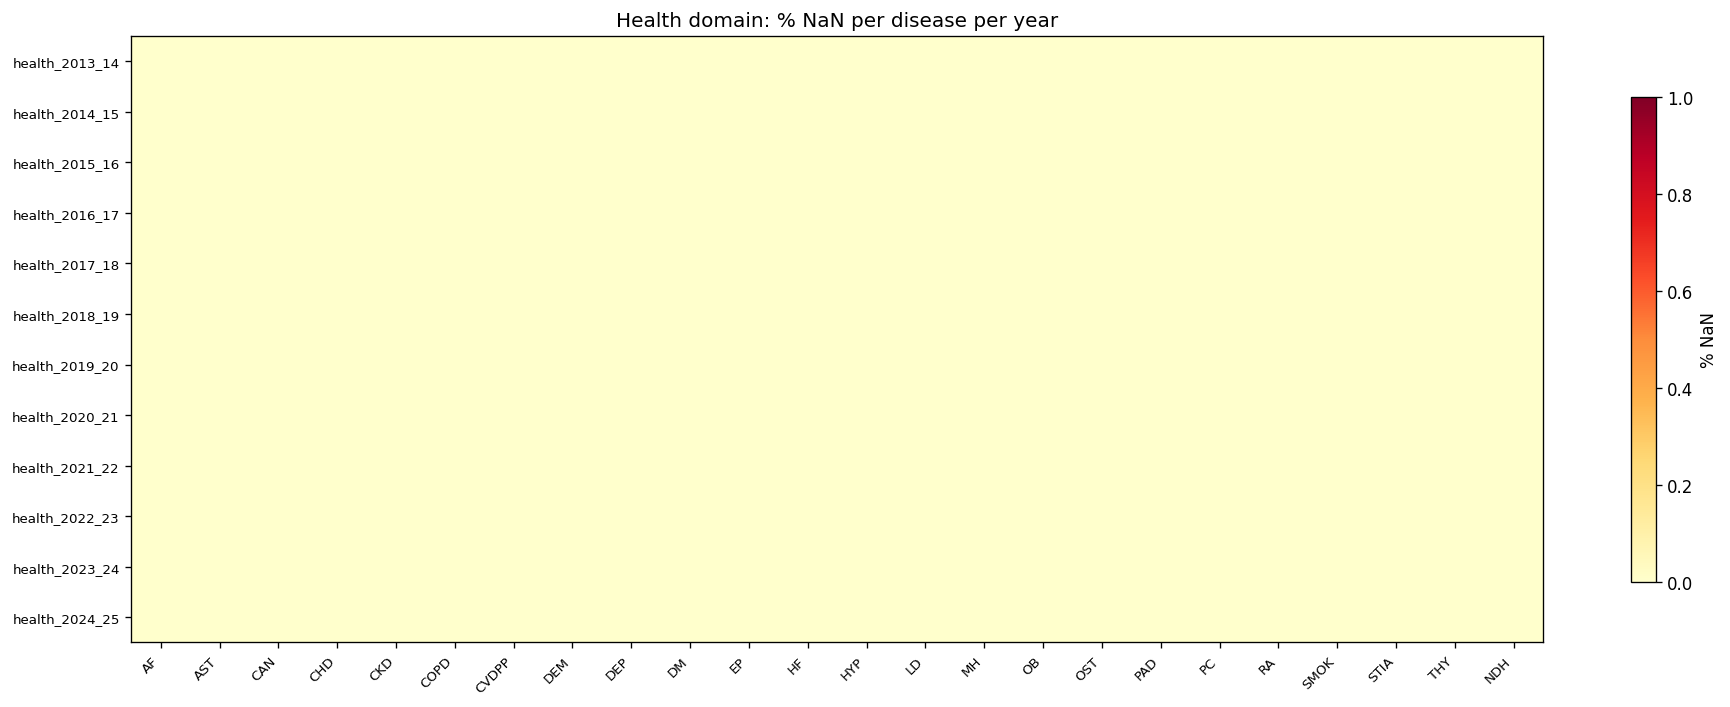

In [4]:
health_files = sorted((out_dir / "health").glob("health_*.csv"))

nan_matrix = []
for f in health_files:
    df = pd.read_csv(f)
    rate_cols = [c for c in df.columns if c.endswith("_afflicted_rate")]
    nan_pcts = {col: df[col].isna().mean() * 100 for col in rate_cols}
    nan_pcts["file"] = f.stem
    nan_matrix.append(nan_pcts)

nan_mx = pd.DataFrame(nan_matrix).set_index("file")

fig, ax = plt.subplots(figsize=(16, 6))
im = ax.imshow(nan_mx.values, aspect="auto", cmap="YlOrRd", vmin=0, vmax=max(nan_mx.values.max(), 1))
ax.set_xticks(range(len(nan_mx.columns)))
ax.set_xticklabels([c.replace("_afflicted_rate", "") for c in nan_mx.columns],
                    rotation=45, ha="right", fontsize=8)
ax.set_yticks(range(len(nan_mx.index)))
ax.set_yticklabels(nan_mx.index, fontsize=8)
ax.set_title("Health domain: % NaN per disease per year")
plt.colorbar(im, label="% NaN", shrink=0.8)
fig.tight_layout()
plt.show()

## 4. Population totals vs known England population

ONS mid-year estimates for England (approximate):
2014: 54.3M, 2018: 55.9M, 2020: 56.5M, 2024: ~56.5M

Population totals from claimant count outputs:
 year  total_pop
 2014 54307508.0
 2015 54777149.0
 2016 55258776.0
 2017 55610198.0
 2018 55967959.0
 2019 56277868.0
 2020 56541086.0
 2021 56541086.0
 2022 56541086.0
 2023 56541086.0
 2024 56541086.0


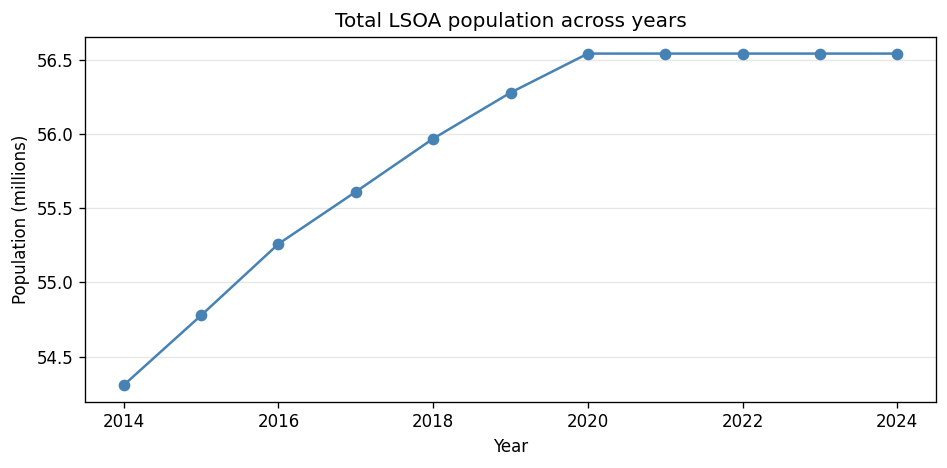

In [5]:
pop_series = []
for f in sorted((out_dir / "claimant_counts").glob("claimant_counts_*.csv")):
    year = int(f.stem.split("_")[-1])
    df = pd.read_csv(f)
    pop_series.append({"year": year, "total_pop": df["pop"].sum()})

pop_df = pd.DataFrame(pop_series)
print("Population totals from claimant count outputs:")
print(pop_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(pop_df["year"], pop_df["total_pop"] / 1e6, "o-", color="steelblue")
ax.set_ylabel("Population (millions)")
ax.set_xlabel("Year")
ax.set_title("Total LSOA population across years")
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
plt.show()

## 5. Column consistency across years

Check that each domain produces the same set of columns across all years.

In [6]:
for domain, files in domains.items():
    col_sets = {}
    for f in files:
        df = pd.read_csv(f, nrows=0)
        col_sets[f.name] = set(df.columns)

    all_cols = list(col_sets.values())
    if len(set(frozenset(c) for c in all_cols)) == 1:
        print(f"{domain}: columns consistent across {len(files)} files ({len(all_cols[0])} columns)")
    else:
        # Show which files differ
        reference = all_cols[0]
        names = list(col_sets.keys())
        for i, (name, cols) in enumerate(col_sets.items()):
            added = cols - reference
            removed = reference - cols
            if added or removed:
                print(f"{domain}/{name}: +{added or '{}'} -{removed or '{}'}")

claimant_counts: columns consistent across 11 files (5 columns)
crime: columns consistent across 11 files (31 columns)
health: columns consistent across 12 files (51 columns)


## 6. Value range sanity checks

Rates should be between 0 and 1 (or at most a small multiple for crime
counts that can exceed population in high-crime areas).

In [7]:
range_issues = []

for domain, files in domains.items():
    for f in files:
        df = pd.read_csv(f)
        rate_cols = [c for c in df.columns if "_rate" in c]
        for col in rate_cols:
            series = df[col].dropna()
            if len(series) == 0:
                continue
            max_val = series.max()
            min_val = series.min()
            # Flag rates > 1 (may be valid for crime, but worth noting)
            threshold = 5 if domain == "crime" else 1
            if max_val > threshold:
                range_issues.append({
                    "domain": domain,
                    "file": f.name,
                    "column": col,
                    "max": max_val,
                    "issue": f"max > {threshold}",
                })
            if min_val < 0:
                range_issues.append({
                    "domain": domain,
                    "file": f.name,
                    "column": col,
                    "min": min_val,
                    "issue": "negative",
                })

if range_issues:
    print("Value range issues:")
    print(pd.DataFrame(range_issues).to_string(index=False))
else:
    print("All rate columns within expected ranges.")

All rate columns within expected ranges.
